In [1]:
#Import necessary libraries
import praw
import json
import time
import os
import random
from datetime import datetime
from pyspark.sql import SparkSession
from pyspark.sql.functions import explode, split, lower, col, desc, size, unix_timestamp, min as spark_min, max as spark_max

In [2]:
# initializing Reddit API client
reddit = praw.Reddit(
    client_id="cnkDJ7fZhXwfj9k476Q20A",
    client_secret="zqrHFk_Av05EM8WcDKE_fc0dDgHkxA",
    user_agent="KavOrla:v1.0 (by /u/YourRedditUsername)"
)

In [3]:
# Start Spark session
spark = SparkSession.builder \
    .appName("RedditLiveStockAnalytics") \
    .master("local[*]") \
    .getOrCreate()

25/05/05 21:55:56 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


In [4]:
# setting file for the full session data
fixed_filename = "/tmp/reddit_collected_posts.json"
if os.path.exists(fixed_filename):
    os.remove(fixed_filename)

In [5]:
# choosing subreddits with stock-related content
subreddits = ["stocks", "wallstreetbets", "StockMarket", "investing"]

In [6]:
#get posts
def fetch_reddit_posts(duration_sec=30):
    chosen_subreddit = random.choice(subreddits)
    print(f"\n Fetching posts from r/{chosen_subreddit} for {duration_sec} seconds...")
    posts = []
    start_time = time.time()
    while (time.time() - start_time) < duration_sec:
        try:
            subreddit = reddit.subreddit(chosen_subreddit)
            for post in subreddit.new(limit=5):
                post_data = {
                    "id": post.id,
                    "title": post.title,
                    "selftext": post.selftext if post.selftext else "",
                    "created_utc": post.created_utc
                }
                posts.append(post_data)
            time.sleep(5)
        except Exception as e:
            print(f"Error fetching posts: {e}")
            time.sleep(5)
    return posts

In [7]:
#putting posts into the file
def append_posts_to_file(posts, filename):
    with open(filename, 'a') as f:
        for post in posts:
            json.dump(post, f)
            f.write("\n")

In [8]:
#analysis of the reddit posts

def analyze_posts(posts):
    if not posts:
        print("No posts to analyze.")
        return

    temp_batch_file = "/tmp/reddit_temp_batch.json"
    with open(temp_batch_file, 'w') as f:
        for post in posts:
            json.dump(post, f)
            f.write("\n")

    reddit_df = spark.read.json(f"file://{temp_batch_file}")

    # Word frequency analysis
    reddit_text_df = reddit_df.selectExpr("concat(coalesce(title, ''), ' ', coalesce(selftext, '')) as text")
    words_df = reddit_text_df.select(
        explode(split(lower(col("text")), "\\W+")).alias("word")
    ).filter(col("word") != "")
    word_count_df = words_df.groupBy("word").count().orderBy(desc("count"))

    print("\n Top 20 Words in this batch:")
    word_count_df.show(20, truncate=False)

    max_count = word_count_df.agg({"count": "max"}).collect()[0][0]
    print(f"\nWord(s) with maximum occurrence in this batch ({max_count} times):")
    word_count_df.filter(col("count") == max_count).show(truncate=False)

    # calculating average title length (in words)
    avg_title_len = reddit_df.selectExpr("size(split(title, ' ')) as title_len") \
                             .agg({"title_len": "avg"}) \
                             .collect()[0][0]
    print(f"\n Average Title Length: {avg_title_len:.2f} words")

    # fiding number of posts with empty selftext
    empty_selftext_count = reddit_df.filter(col("selftext") == "").count()
    print(f"Posts with No Body (empty selftext): {empty_selftext_count}")

    # getting time difference between newest and oldest post
    time_df = reddit_df.withColumn("timestamp", unix_timestamp(col("created_utc").cast("timestamp")))
    min_ts, max_ts = time_df.agg(spark_min("timestamp"), spark_max("timestamp")).first()
    if min_ts and max_ts:
        diff_seconds = int(max_ts - min_ts)
        print(f"Time difference between oldest and newest post: {diff_seconds} seconds")
    else:
        print("Could not compute time difference (missing timestamps)")


In [9]:
# Main batch loop
while True:
    posts = fetch_reddit_posts(duration_sec=30)
    append_posts_to_file(posts, fixed_filename)
    analyze_posts(posts)

    choice = input("\n Fetch and analyze another batch? (yes/no): ").strip().lower()
    if choice != 'yes':
        print("\n Program exiting. Thank you!")
        break

spark.stop()


 Fetching posts from r/StockMarket for 30 seconds...



 Top 20 Words in this batch:
+----------+-----+
|word      |count|
+----------+-----+
|the       |156  |
|in        |120  |
|and       |108  |
|to        |108  |
|s         |108  |
|on        |96   |
|of        |90   |
|a         |84   |
|palantir  |66   |
|for       |60   |
|billion   |54   |
|is        |54   |
|its       |48   |
|i         |48   |
|as        |48   |
|by        |42   |
|it        |42   |
|3         |42   |
|government|42   |
|sales     |36   |
+----------+-----+
only showing top 20 rows


Word(s) with maximum occurrence in this batch (156 times):
+----+-----+
|word|count|
+----+-----+
|the |156  |
+----+-----+


 Average Title Length: 11.60 words
Posts with No Body (empty selftext): 6
Time difference between oldest and newest post: 6884 seconds

 Fetch and analyze another batch? (yes/no): yes

 Fetching posts from r/StockMarket for 30 seconds...

 Top 20 Words in this batch:
+----------+-----+
|word      |count|
+----------+-----+
|the       |156  |
|in        |120  

Tmp file in system:
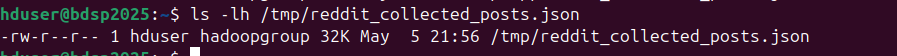

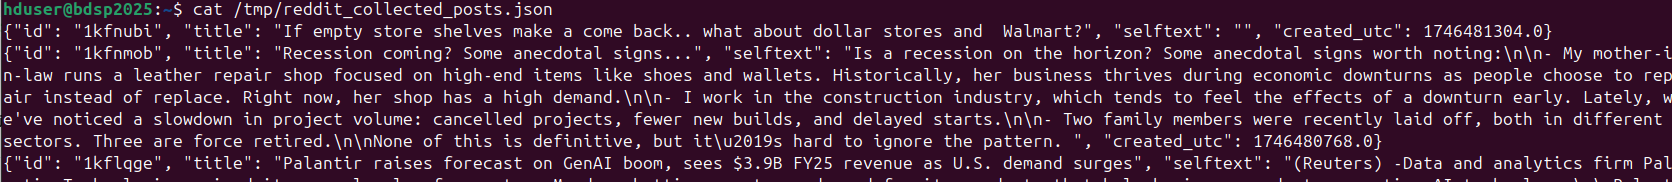
less /tmp/reddit_collected_posts.json
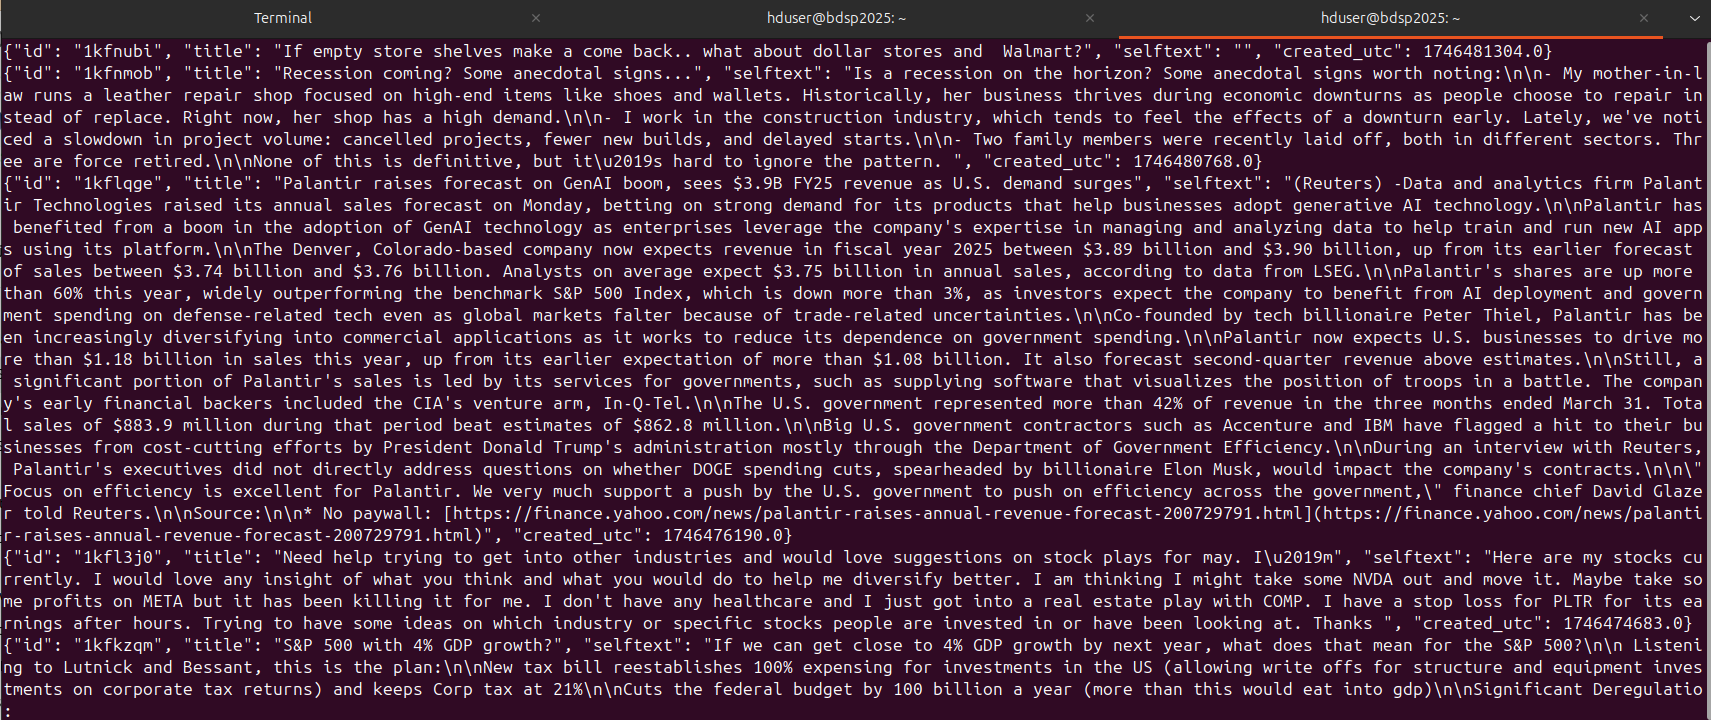

#### References
RW_Reddit_Posts.ipynb file from Dr Muhammad Iqbal, Senior Lecturer, CCT College Dublin.